# ML Pipeline

## Objectives

* Create Predictive model for model validation

## Inputs

* Full data set from (/data/processed/04_df_all_data_1990_2024.csv)

## Outputs

* Modelling dataset from (data/processed/03_df_modelling_all_data_1990_2024.csv)
* Predictive model and plots





---

# Change working directory

* We are assuming you will store the notebooks in a subfolder, therefore when running the notebook in the editor, you will need to change the working directory

We need to change the working directory from its current folder to its parent folder
* We access the current directory with os.getcwd()

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\world_carbon_money_heat_analysis\\jupyter_notebooks'

We want to make the parent of the current directory the new current directory
* os.path.dirname() gets the parent directory
* os.chir() defines the new current directory

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


Confirm the new current directory

In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\naqas\\OneDrive\\Documents\\Coding\\CI_Projects\\world_carbon_money_heat_analysis'

---

# Import Packages

In [29]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_validate

---

# Import dataset and create modelling dataset

In [5]:
full_clean_data_df = pd.read_csv("data/processed/04_df_all_data_1990_2024.csv")
full_clean_data_df

,country_code_iso3,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc,other_renewables,bioenergy,solar,wind,hydropower,nuclear,oil,gas,coal
0,AFG,Afghanistan,1990,0.168054,12045664.0,NaN,13.25,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AFG,Afghanistan,1991,0.156411,12238879.0,NaN,12.70,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AFG,Afghanistan,1992,0.111609,13278983.0,NaN,12.42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AFG,Afghanistan,1993,0.099506,14943175.0,NaN,12.71,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AFG,Afghanistan,1994,0.089462,16250800.0,NaN,12.95,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7468,ZWE,Zimbabwe,2020,0.546847,15526887.0,4527.719881,21.94,0.0,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74
7469,ZWE,Zimbabwe,2021,0.647125,15797220.0,4827.088694,21.89,0.0,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51
7470,ZWE,Zimbabwe,2022,0.761205,16069061.0,5036.761361,21.83,0.0,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92
7471,ZWE,Zimbabwe,2023,0.822681,16340829.0,5218.022665,22.09,0.0,0.12,0.03,0.0,5.46,0.0,0.00,0.0,2.70


There are null values in the dataset due to some data not being documented for some years. The rows are still essential so we will keep these. Instead we will replace the null values with "0"

In [6]:
full_clean_data_df = full_clean_data_df.replace(np.nan,0)
full_clean_data_df

,country_code_iso3,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc,other_renewables,bioenergy,solar,wind,hydropower,nuclear,oil,gas,coal
0,AFG,Afghanistan,1990,0.168054,12045664.0,0.000000,13.25,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00
1,AFG,Afghanistan,1991,0.156411,12238879.0,0.000000,12.70,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00
2,AFG,Afghanistan,1992,0.111609,13278983.0,0.000000,12.42,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00
3,AFG,Afghanistan,1993,0.099506,14943175.0,0.000000,12.71,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00
4,AFG,Afghanistan,1994,0.089462,16250800.0,0.000000,12.95,0.0,0.00,0.00,0.0,0.00,0.0,0.00,0.0,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7468,ZWE,Zimbabwe,2020,0.546847,15526887.0,4527.719881,21.94,0.0,0.10,0.02,0.0,3.81,0.0,0.04,0.0,2.74
7469,ZWE,Zimbabwe,2021,0.647125,15797220.0,4827.088694,21.89,0.0,0.11,0.02,0.0,5.93,0.0,0.00,0.0,2.51
7470,ZWE,Zimbabwe,2022,0.761205,16069061.0,5036.761361,21.83,0.0,0.11,0.03,0.0,5.88,0.0,0.00,0.0,2.92
7471,ZWE,Zimbabwe,2023,0.822681,16340829.0,5218.022665,22.09,0.0,0.12,0.03,0.0,5.46,0.0,0.00,0.0,2.70


Part of the validation includes comparing country's renewable share to it's CO2 output. There is no current "Renewable Share" column. This must be created based off the energy columns present.

In [7]:
renewables = ["other_renewables", "bioenergy", "solar","wind", "hydropower"]
non_renewables= ["nuclear","oil","gas", "coal"]


full_clean_data_df["total_renewable_energy"] = full_clean_data_df[renewables].sum(axis=1)
full_clean_data_df["total_energy_output"] = full_clean_data_df[renewables + non_renewables].sum(axis=1)

full_clean_data_df["total_renewable_share"] = (full_clean_data_df["total_renewable_energy"]/full_clean_data_df["total_energy_output"]) * 100

full_clean_data_df.drop(columns =["total_renewable_energy","total_energy_output"])

full_clean_data_df["total_renewable_share"].describe()

count    4770.000000
mean       32.355826
std        33.059511
min         0.000000
25%         2.682931
50%        19.783622
75%        57.423990
max       100.000000
Name: total_renewable_share, dtype: float64

Lag and Rolling features are created off all numeric columns. This is done as this is time-series data. The lagging and rolling features will allow us to :

1) See the change from the previous year to the next year
2) See any trends based off consistent changes rather than from anomalous years

In [33]:

lag_cols = ["co2_pc","population","gdp_constant_ppp_pc","degc","other_renewables","bioenergy","solar","wind","hydropower","nuclear","oil","gas","coal","total_renewable_share"]

for col in lag_cols:
    full_clean_data_df[f"{col}_lag1"] = (
        full_clean_data_df.groupby("country_name_iso3")[col]
        .transform(lambda x: x.shift(1))
    )


roll_cols = ["co2_pc","population","gdp_constant_ppp_pc","degc","other_renewables","bioenergy","solar","wind","hydropower","nuclear","oil","gas","coal","total_renewable_share"]

for col in roll_cols:
    full_clean_data_df[f"{col}_roll_mean_3"] = (
        full_clean_data_df.groupby("country_name_iso3")[col]
        .transform(lambda x: x.shift(1).rolling(3).mean())
    )


full_clean_data_df

,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc,other_renewables,bioenergy,solar,wind,...,other_renewables_roll_mean_3,bioenergy_roll_mean_3,solar_roll_mean_3,wind_roll_mean_3,hydropower_roll_mean_3,nuclear_roll_mean_3,oil_roll_mean_3,gas_roll_mean_3,coal_roll_mean_3,total_renewable_share_roll_mean_3
13,Afghanistan,2003,0.068608,22733053.0,1815.928200,13.27,0.0,0.00,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
14,Afghanistan,2004,0.052513,23560656.0,1776.918207,13.92,0.0,0.00,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,Afghanistan,2005,0.077424,24404575.0,1908.114782,13.34,0.0,0.00,0.00,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
16,Afghanistan,2006,0.084932,25424100.0,1929.723897,13.81,0.0,0.00,0.00,0.0,...,0.0,0.000000,0.000000,0.0,0.593333,0.0,0.176667,0.0,0.070000,70.689355
17,Afghanistan,2007,0.108063,25909852.0,2155.353068,13.50,0.0,0.00,0.00,0.0,...,0.0,0.000000,0.000000,0.0,0.596667,0.0,0.150000,0.0,0.090000,71.316136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7467,Zimbabwe,2019,0.672290,15271377.0,4993.843839,22.41,0.0,0.19,0.02,0.0,...,0.0,0.190000,0.010000,0.0,4.000000,0.0,0.043333,0.0,3.806667,51.761571
7468,Zimbabwe,2020,0.546847,15526887.0,4527.719881,21.94,0.0,0.10,0.02,0.0,...,0.0,0.176667,0.013333,0.0,4.396667,0.0,0.046667,0.0,3.853333,54.008771
7469,Zimbabwe,2021,0.647125,15797220.0,4827.088694,21.89,0.0,0.11,0.02,0.0,...,0.0,0.160000,0.016667,0.0,4.343333,0.0,0.046667,0.0,3.640000,55.297875
7470,Zimbabwe,2022,0.761205,16069061.0,5036.761361,21.83,0.0,0.11,0.03,0.0,...,0.0,0.133333,0.020000,0.0,4.636667,0.0,0.030000,0.0,3.100000,60.310676


A null sum count is required. This shows the nulls generated from the lagging and rolling columns. 

In [10]:
full_clean_data_df.isnull().sum()

country_code_iso3                       0
country_name_iso3                       0
year                                    0
co2_pc                                  0
population                              0
gdp_constant_ppp_pc                     0
degc                                    0
other_renewables                        0
bioenergy                               0
solar                                   0
wind                                    0
hydropower                              0
nuclear                                 0
oil                                     0
gas                                     0
coal                                    0
total_renewable_energy                  0
total_energy_output                     0
total_renewable_share                2703
co2_pc_lag1                           214
population_lag1                       214
gdp_constant_ppp_pc_lag1              214
degc_lag1                             214
other_renewables_lag1             

All null rows can be dropped.

In [11]:
full_clean_data_df = full_clean_data_df.dropna()
full_clean_data_df

,country_code_iso3,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc,other_renewables,bioenergy,solar,...,other_renewables_roll_mean_3,bioenergy_roll_mean_3,solar_roll_mean_3,wind_roll_mean_3,hydropower_roll_mean_3,nuclear_roll_mean_3,oil_roll_mean_3,gas_roll_mean_3,coal_roll_mean_3,total_renewable_share_roll_mean_3
13,AFG,Afghanistan,2003,0.068608,22733053.0,1815.928200,13.27,0.0,0.00,0.00,...,0.0,0.000000,0.000000,0.0,0.456667,0.0,0.143333,0.0,0.026667,71.973447
14,AFG,Afghanistan,2004,0.052513,23560656.0,1776.918207,13.92,0.0,0.00,0.00,...,0.0,0.000000,0.000000,0.0,0.563333,0.0,0.150000,0.0,0.056667,73.522592
15,AFG,Afghanistan,2005,0.077424,24404575.0,1908.114782,13.34,0.0,0.00,0.00,...,0.0,0.000000,0.000000,0.0,0.583333,0.0,0.156667,0.0,0.063333,72.996695
16,AFG,Afghanistan,2006,0.084932,25424100.0,1929.723897,13.81,0.0,0.00,0.00,...,0.0,0.000000,0.000000,0.0,0.593333,0.0,0.176667,0.0,0.070000,70.689355
17,AFG,Afghanistan,2007,0.108063,25909852.0,2155.353068,13.50,0.0,0.00,0.00,...,0.0,0.000000,0.000000,0.0,0.596667,0.0,0.150000,0.0,0.090000,71.316136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7467,ZWE,Zimbabwe,2019,0.672290,15271377.0,4993.843839,22.41,0.0,0.19,0.02,...,0.0,0.190000,0.010000,0.0,4.000000,0.0,0.043333,0.0,3.806667,51.761571
7468,ZWE,Zimbabwe,2020,0.546847,15526887.0,4527.719881,21.94,0.0,0.10,0.02,...,0.0,0.176667,0.013333,0.0,4.396667,0.0,0.046667,0.0,3.853333,54.008771
7469,ZWE,Zimbabwe,2021,0.647125,15797220.0,4827.088694,21.89,0.0,0.11,0.02,...,0.0,0.160000,0.016667,0.0,4.343333,0.0,0.046667,0.0,3.640000,55.297875
7470,ZWE,Zimbabwe,2022,0.761205,16069061.0,5036.761361,21.83,0.0,0.11,0.03,...,0.0,0.133333,0.020000,0.0,4.636667,0.0,0.030000,0.0,3.100000,60.310676


The country code column is extra and not required so this can be dropped.

In [12]:
full_clean_data_df = full_clean_data_df.drop("country_code_iso3", axis=1)
full_clean_data_df

,country_name_iso3,year,co2_pc,population,gdp_constant_ppp_pc,degc,other_renewables,bioenergy,solar,wind,...,other_renewables_roll_mean_3,bioenergy_roll_mean_3,solar_roll_mean_3,wind_roll_mean_3,hydropower_roll_mean_3,nuclear_roll_mean_3,oil_roll_mean_3,gas_roll_mean_3,coal_roll_mean_3,total_renewable_share_roll_mean_3
13,Afghanistan,2003,0.068608,22733053.0,1815.928200,13.27,0.0,0.00,0.00,0.0,...,0.0,0.000000,0.000000,0.0,0.456667,0.0,0.143333,0.0,0.026667,71.973447
14,Afghanistan,2004,0.052513,23560656.0,1776.918207,13.92,0.0,0.00,0.00,0.0,...,0.0,0.000000,0.000000,0.0,0.563333,0.0,0.150000,0.0,0.056667,73.522592
15,Afghanistan,2005,0.077424,24404575.0,1908.114782,13.34,0.0,0.00,0.00,0.0,...,0.0,0.000000,0.000000,0.0,0.583333,0.0,0.156667,0.0,0.063333,72.996695
16,Afghanistan,2006,0.084932,25424100.0,1929.723897,13.81,0.0,0.00,0.00,0.0,...,0.0,0.000000,0.000000,0.0,0.593333,0.0,0.176667,0.0,0.070000,70.689355
17,Afghanistan,2007,0.108063,25909852.0,2155.353068,13.50,0.0,0.00,0.00,0.0,...,0.0,0.000000,0.000000,0.0,0.596667,0.0,0.150000,0.0,0.090000,71.316136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7467,Zimbabwe,2019,0.672290,15271377.0,4993.843839,22.41,0.0,0.19,0.02,0.0,...,0.0,0.190000,0.010000,0.0,4.000000,0.0,0.043333,0.0,3.806667,51.761571
7468,Zimbabwe,2020,0.546847,15526887.0,4527.719881,21.94,0.0,0.10,0.02,0.0,...,0.0,0.176667,0.013333,0.0,4.396667,0.0,0.046667,0.0,3.853333,54.008771
7469,Zimbabwe,2021,0.647125,15797220.0,4827.088694,21.89,0.0,0.11,0.02,0.0,...,0.0,0.160000,0.016667,0.0,4.343333,0.0,0.046667,0.0,3.640000,55.297875
7470,Zimbabwe,2022,0.761205,16069061.0,5036.761361,21.83,0.0,0.11,0.03,0.0,...,0.0,0.133333,0.020000,0.0,4.636667,0.0,0.030000,0.0,3.100000,60.310676


The dataframe can now be exported as a modelling dataset.

In [13]:
full_clean_data_df.to_csv("data/processed/03_df_modelling_all_data_1990_2024.csv", index= False)
print("Modelling file has been created and exported")

Modelling file has been created and exported


---

The modelling dataset created can now be used to create a modelling dataframe.

In [14]:
modelling_data_df = pd.read_csv("data/processed/03_df_modelling_all_data_1990_2024.csv")
modelling_data_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4175 entries, 0 to 4174
Data columns (total 46 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   country_name_iso3                  4175 non-null   str    
 1   year                               4175 non-null   int64  
 2   co2_pc                             4175 non-null   float64
 3   population                         4175 non-null   float64
 4   gdp_constant_ppp_pc                4175 non-null   float64
 5   degc                               4175 non-null   float64
 6   other_renewables                   4175 non-null   float64
 7   bioenergy                          4175 non-null   float64
 8   solar                              4175 non-null   float64
 9   wind                               4175 non-null   float64
 10  hydropower                         4175 non-null   float64
 11  nuclear                            4175 non-null   float64
 12  oil

---

### _Define Pipelines_

For models being used, we can define pipelines.

In [15]:
lr_pipeline = Pipeline(
    [("scaler", StandardScaler()),
     ("model", LinearRegression())]
)

qr_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler2", StandardScaler()),
        ("model", LinearRegression())
    ]
)


models = {
    "Linear Regression" : lr_pipeline,
    "Quadratic Regression" : qr_pipeline
}

Next, we can test the models against each country to see the following:

* MAE (mean absolute error) - Mean Absolute Error (MAE) is a metric used to measure the accuracy of regression models by calculating the average magnitude of errors between predicted and actual values.
* RMSE (mean squared error) - Mean Squared Error (MSE) measures the average squared difference between estimated values and the actual value.
* R2 score - The score, also known as the coefficient of determination, is a statistical measure that represents the proportion of variance.

In [16]:
country_results = []

for country in modelling_data_df["country_name_iso3"].unique():
    country_df = modelling_data_df[modelling_data_df["country_name_iso3"] == country].sort_values("year")
    
    X_c = country_df[["total_renewable_share"]]
    y_c = country_df["co2_pc"]
    
    # Skip countries with too few data points
    if len(country_df) < 10:
        continue
    
    lr_pipeline.fit(X_c, y_c)
    preds = lr_pipeline.predict(X_c)
    
    country_results.append({
        "country": country,
        "MAE":  mean_absolute_error(y_c, preds),
        "RMSE": np.sqrt(mean_squared_error(y_c, preds)),
        "R2":   r2_score(y_c, preds),
        "n":    len(country_df)
    })

country_results_df = pd.DataFrame(country_results).sort_values("R2", ascending=False)
print(country_results_df)

                      country       MAE      RMSE        R2   n
48                    Denmark  0.327260  0.411535  0.961863  22
89                      Italy  0.212278  0.271902  0.950836  22
46                    Czechia  0.289225  0.354975  0.944229  22
69                    Germany  0.252150  0.295048  0.940779  22
186            United Kingdom  0.381792  0.444604  0.936024  22
..                        ...       ...       ...       ...  ..
73                    Grenada  0.239646  0.292565  0.000000  20
76              Guinea-Bissau  0.027640  0.035820  0.000000  20
153   St. Pierre and Miquelon  0.510624  0.588479  0.000000  20
150                St. Helena  0.159322  0.301383  0.000000  20
183  Turks and Caicos Islands  0.560989  0.723522  0.000000  21

[196 rows x 5 columns]


Next, we will do an analysis of the top 15 and bottom 15 countries of the dataset based off the R2 scores.

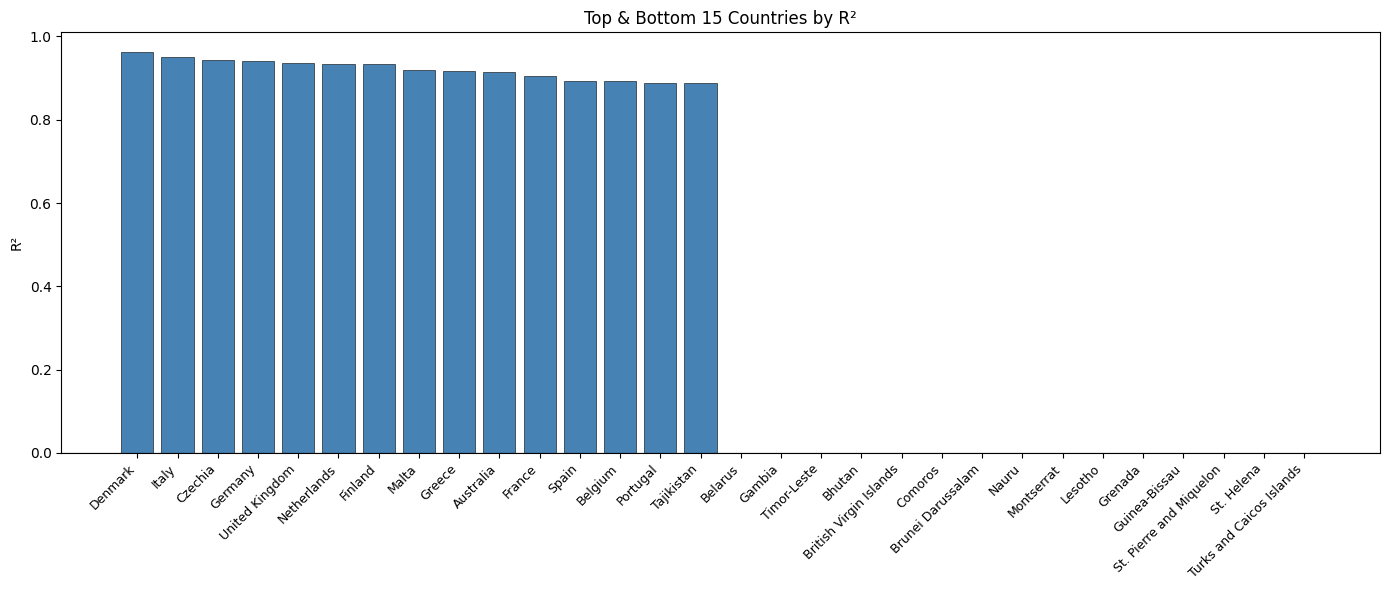

In [38]:
n = 15  

top_n    = country_results_df.head(n)
bottom_n = country_results_df.tail(n)
subset   = pd.concat([top_n, bottom_n])

plt.figure(figsize=(14, 6))
plt.bar(
    subset["country"],
    subset["R2"],
    color=["steelblue" if r > 0 else "coral" for r in subset["R2"]],
    edgecolor="black",
    linewidth=0.4
)
plt.axhline(0, color="black", linewidth=0.8)
plt.xticks(rotation=45, ha="right", fontsize=9)
plt.ylabel("R²")
plt.title(f"Top & Bottom {n} Countries by R²")
plt.tight_layout()
plt.show()

Finally, a comparison is plotted for the top 10 and bottom 10 GDP countries (based off the average of the years throughout the dataset range). In this comparison we see:

* Renewable share in the date range
* Actual CO2 output in the date range
* Predicted CO2 output in the date range

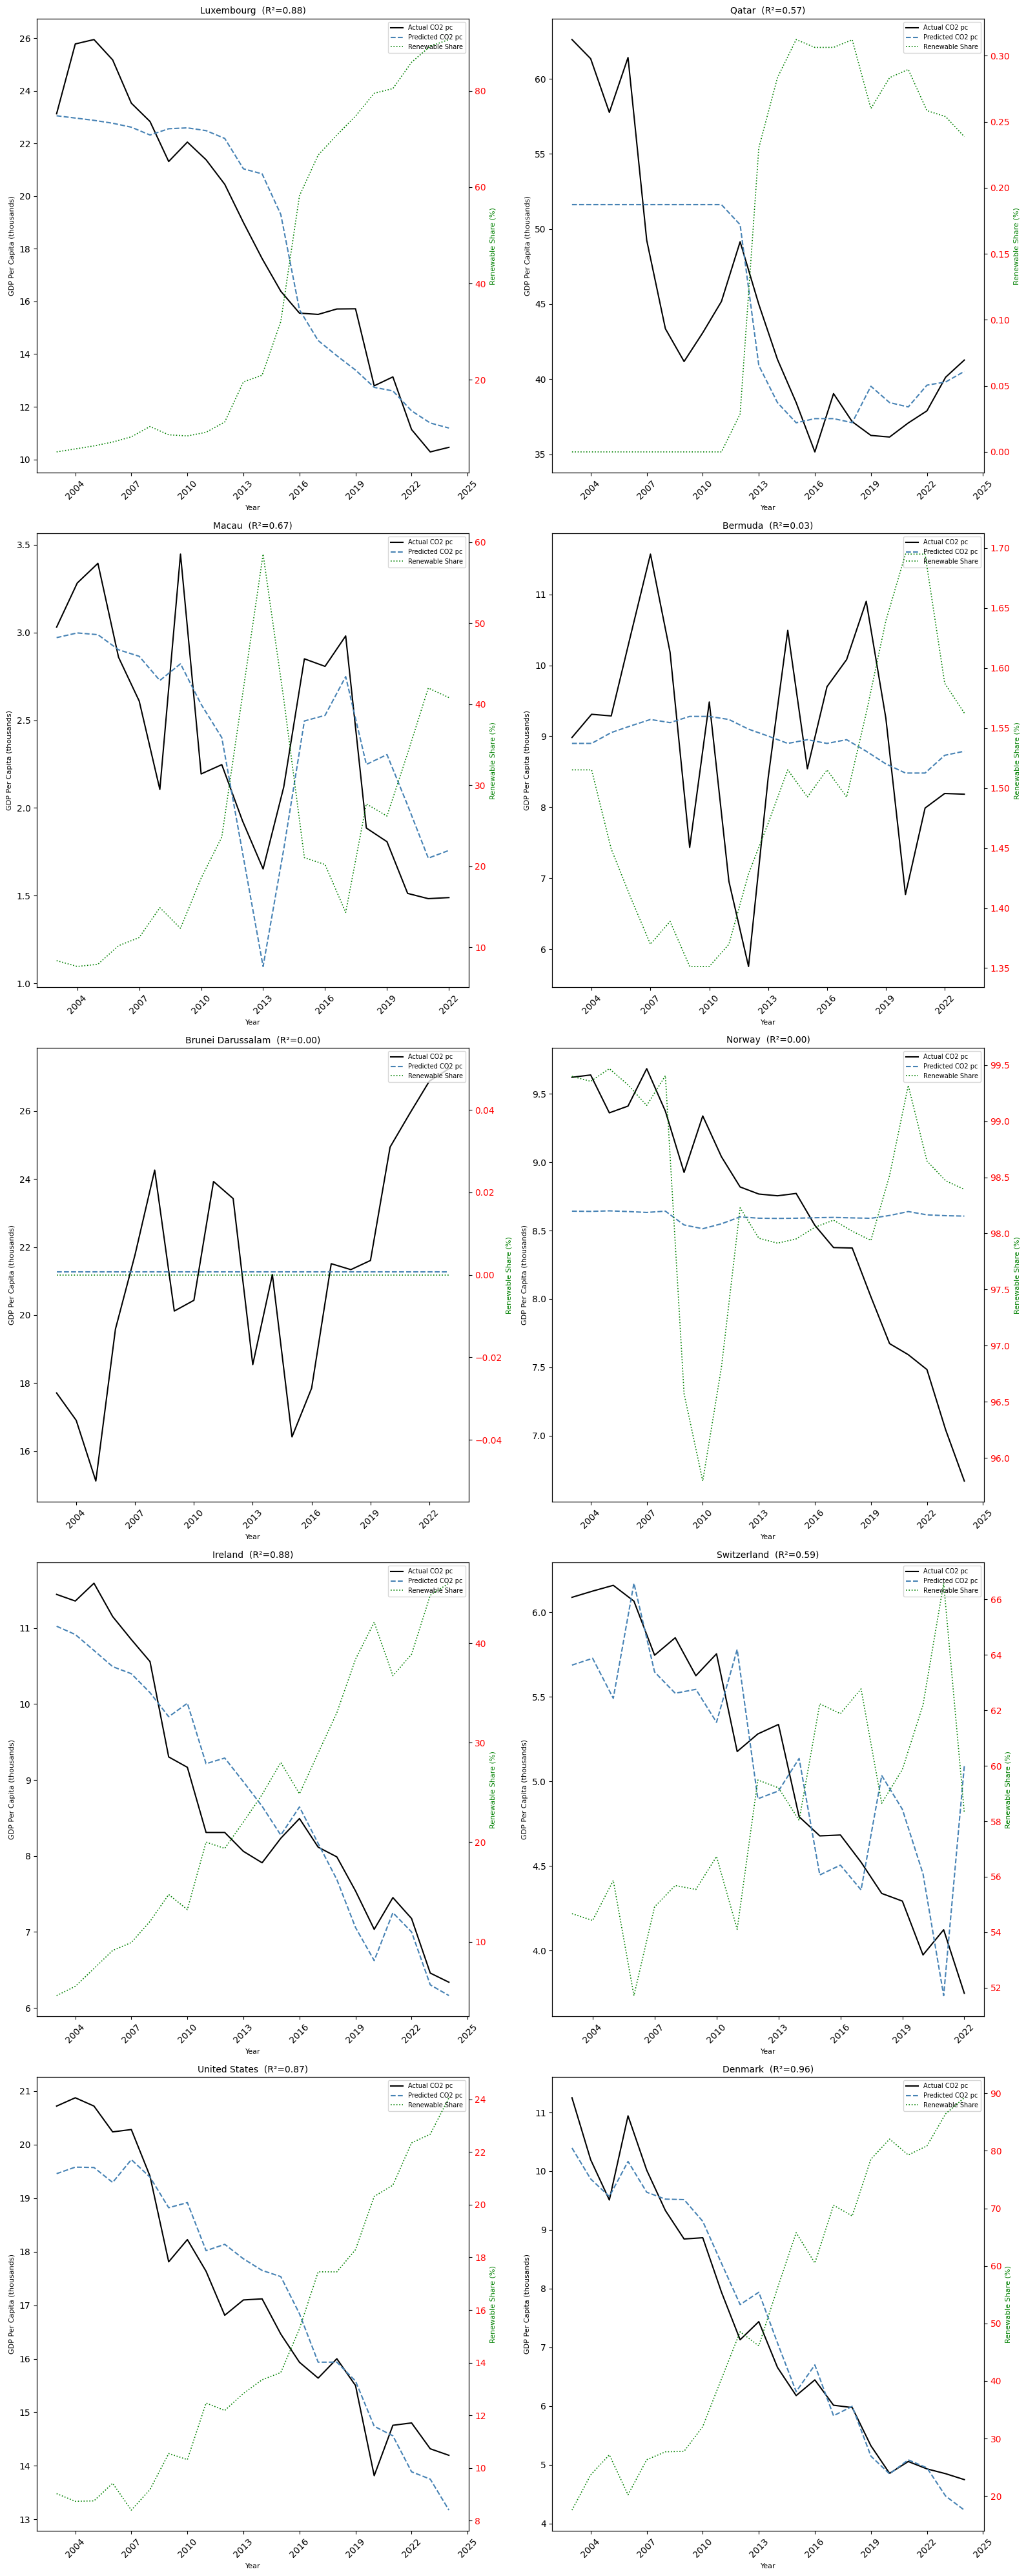

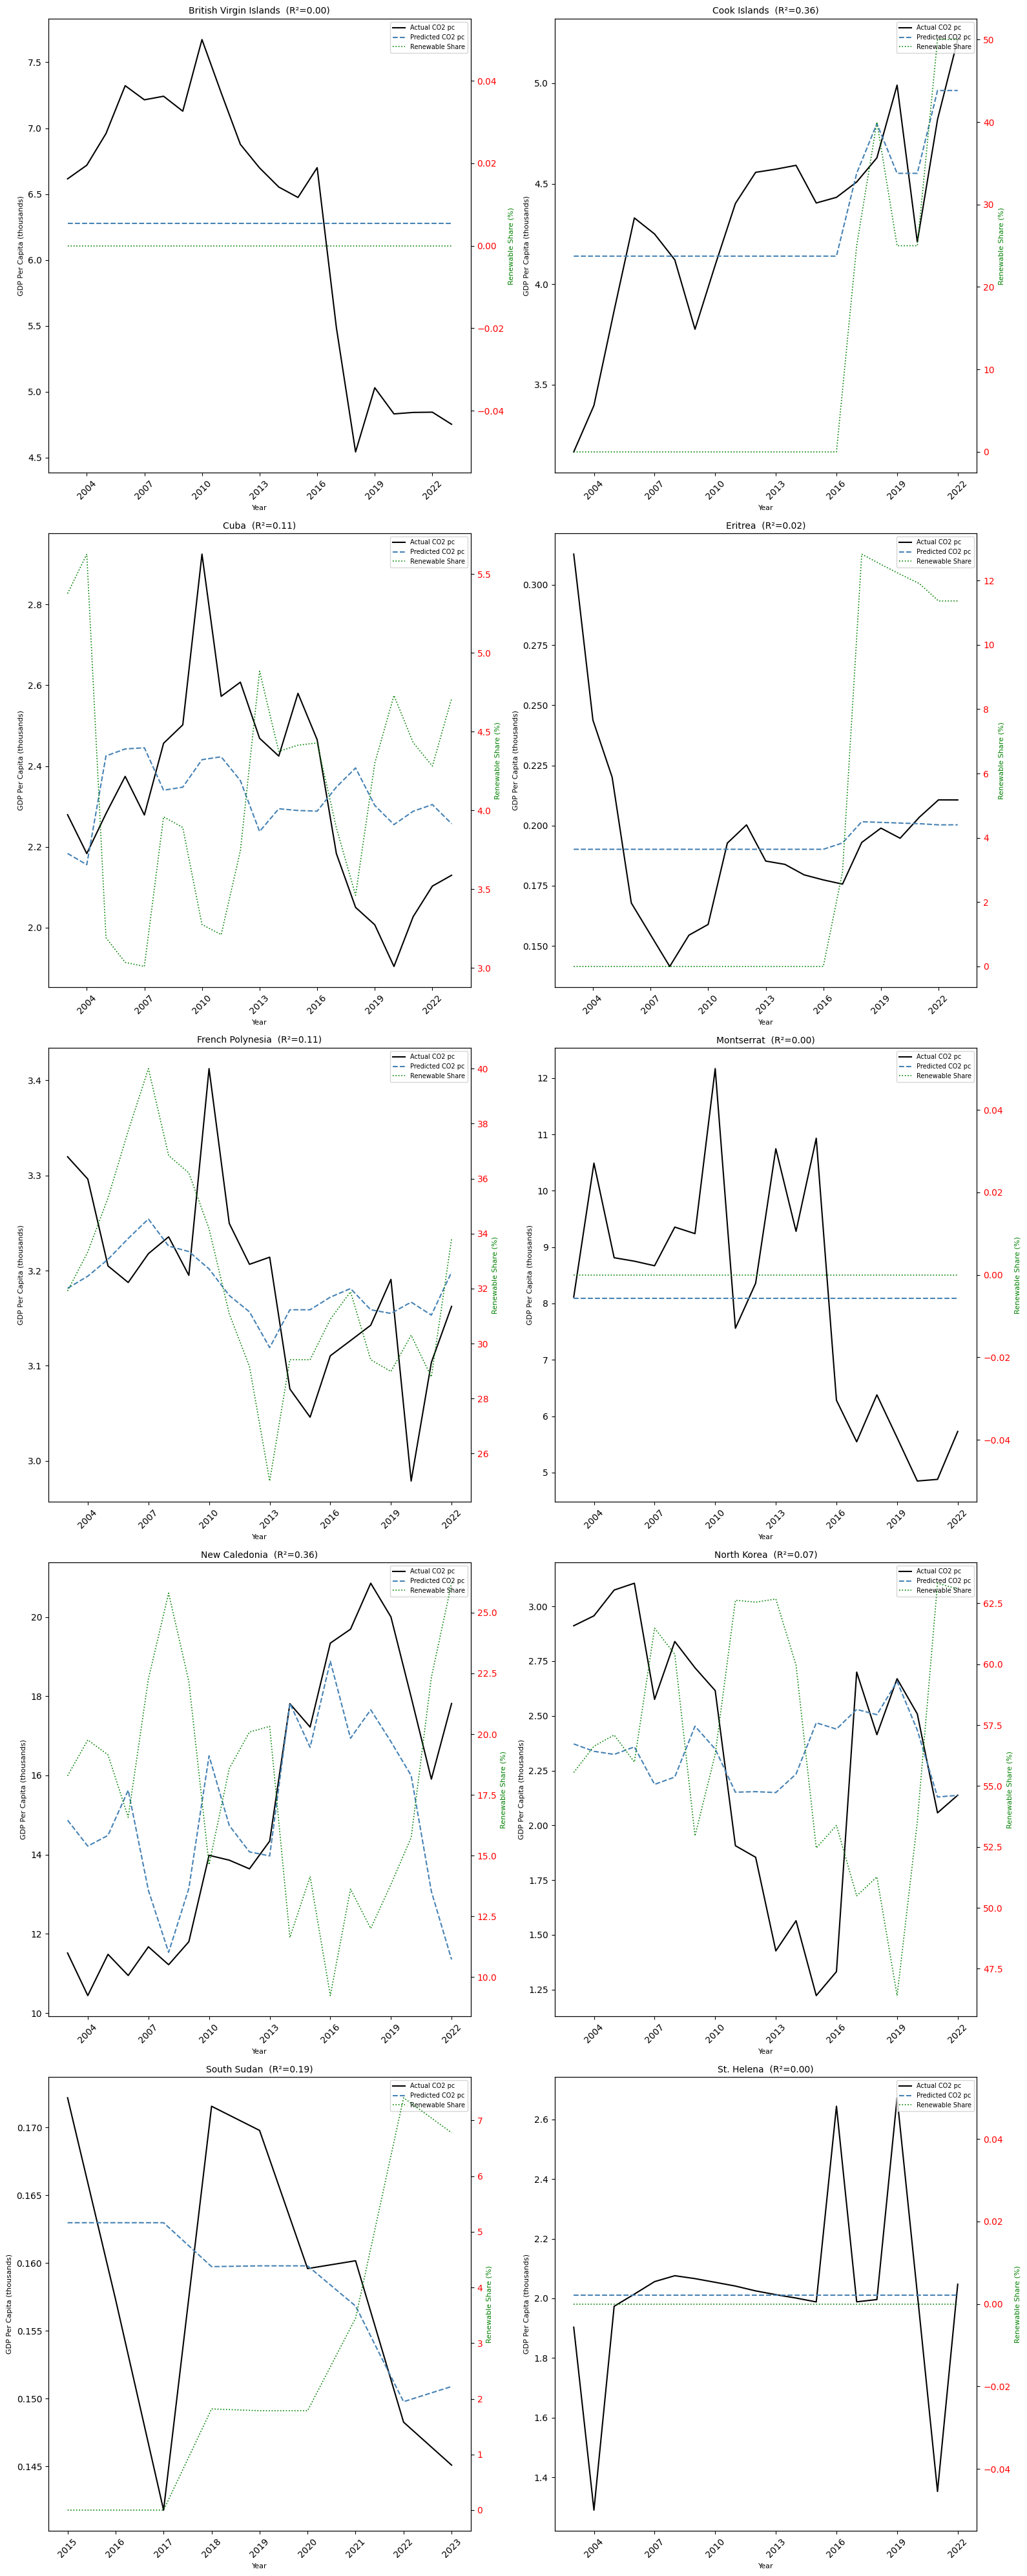

In [41]:
avg_gdp = modelling_data_df.groupby("country_name_iso3")["gdp_constant_ppp_pc"].mean()

top_10_high = avg_gdp.nlargest(10).index.tolist()
top_10_low  = avg_gdp.nsmallest(10).index.tolist()

def plot_country_predictions(country_list, title):
    n_cols = 2
    n_rows = math.ceil(len(country_list) / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 8))
    axes = axes.flatten()
    
    for i, country in enumerate(country_list):
        country_df = modelling_data_df[modelling_data_df["country_name_iso3"] == country].sort_values("year")
        
        X_c = country_df[["total_renewable_share"]]
        y_c = country_df["co2_pc"]
        years = country_df["year"].values
        
        lr_pipeline.fit(X_c, y_c)
        preds = lr_pipeline.predict(X_c)
        r2    = r2_score(y_c, preds)
        
        ax  = axes[i]
        ax2 = ax.twinx()
        
        ax.plot(years, y_c.values, color="black",     linewidth=1.5, label="Actual CO2 pc")
        ax.plot(years, preds,      color="steelblue", linewidth=1.5, linestyle="--", label="Predicted CO2 pc")
        ax2.plot(years, X_c["total_renewable_share"].values, color="green", linewidth=1.2, linestyle=":", label="Renewable Share")
        
        ax.set_title(f"{country}  (R²={r2:.2f})", fontsize=10)
        ax.set_xlabel("Year", fontsize=8)
        ax.set_ylabel("GDP Per Capita (thousands)", fontsize=8, color="black")
        ax2.set_ylabel("Renewable Share (%)", fontsize=8, color="green")
        ax2.tick_params(axis="y", labelcolor="red")
        
        # Force whole number year ticks
        ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
        ax.tick_params(axis="x", rotation=45)
        
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2, fontsize=7, loc="upper right")
    
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    
    #plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()

plot_country_predictions(top_10_high, "Top 10 Highest GDP Per Capita — Renewable Share vs CO2 Over Time")
plot_country_predictions(top_10_low,  "Top 10 Lowest GDP Per Capita — Renewable Share vs CO2 Over Time")

---